In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset, specifying the encoding
df = pd.read_csv("/content/Job opportunities.csv", encoding='latin-1')  # or 'ISO-8859-1'
# If 'latin-1' doesn't work, try 'ISO-8859-1' or other encodings

df.head()

,Job Title,Job Description,Required Skills,Salary Range,Location,Company,Experience Level,Industry,Job Type,Date Posted
0,Software Engineer,Develop software,"Java, Python","£40,000 - £60,000",London,ABC Tech,Entry-Level,Technology,Full-Time,05-01-2023
1,Data Analyst,Analyze data,"SQL, Excel","£35,000 - £50,000",Manchester,XYZ Analytics,Junior,Analytics,Full-Time,10-02-2023
2,Network Engineer,Maintain networks,"Cisco, WAN","£45,000 - £70,000",Birmingham,Network Solutions,Mid-Level,Networking,Full-Time,15-03-2023
3,Cloud Architect,Design cloud,"AWS, Azure","£60,000 - £90,000",Edinburgh,Cloud Innovators,Senior,Cloud Computing,Full-Time,20-04-2023
4,Cybersecurity Analyst,Protect data,Cybersecurity,"£50,000 - £80,000",Glasgow,SecureGuard,Mid-Level,Security,Full-Time,25-05-2023


In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Load the dataset with proper encoding
file_path = "Job opportunities.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1")

# Standardize column names by stripping spaces and converting to lowercase
df.columns = df.columns.str.strip().str.lower()

# Check if necessary columns exist
required_columns = ['job title', 'job description', 'required skills', 'company', 'salary range']
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"Warning: The following required columns are missing: {missing_columns}")
else:
    # Text feature extraction (Skills + Job Description)
    df['combined_text'] = df['required skills'].fillna('') + ' ' + df['job description'].fillna('')

    # Convert text into numerical features using TF-IDF
    vectorizer = TfidfVectorizer()
    features = vectorizer.fit_transform(df['combined_text'])

    # Preprocess salary range: Extract average salary
    def extract_avg_salary(salary):
        salary = re.sub(r'[^0-9\-]', '', str(salary))  # Remove non-numeric characters except '-'
        if '-' in salary:
            parts = salary.split('-')
            if len(parts) == 2:
                return (float(parts[0]) + float(parts[1])) / 2  # Take the average
        try:
            return float(salary)
        except ValueError:
            return None  # Handle missing or invalid values

    df['salary range'] = df['salary range'].apply(extract_avg_salary)
    df = df.dropna(subset=['salary range'])  # Drop rows with missing salary
    target = df['salary range']

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

    # Train a linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate mean absolute error
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Mean Absolute Error: {mae:.2f}")


Mean Absolute Error: 6514.70


Mean Absolute Error: 6514.70


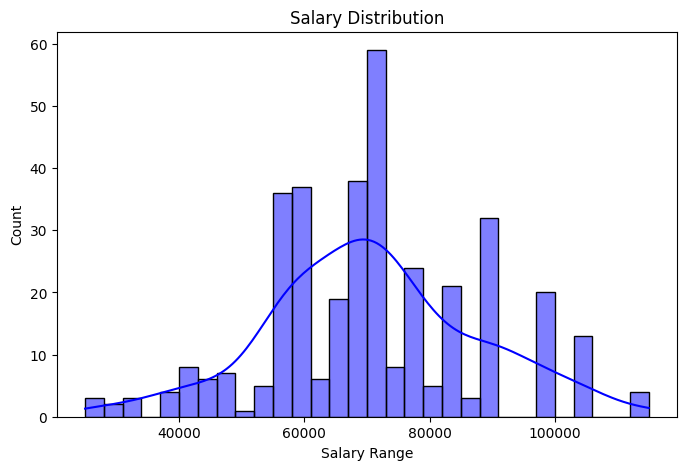

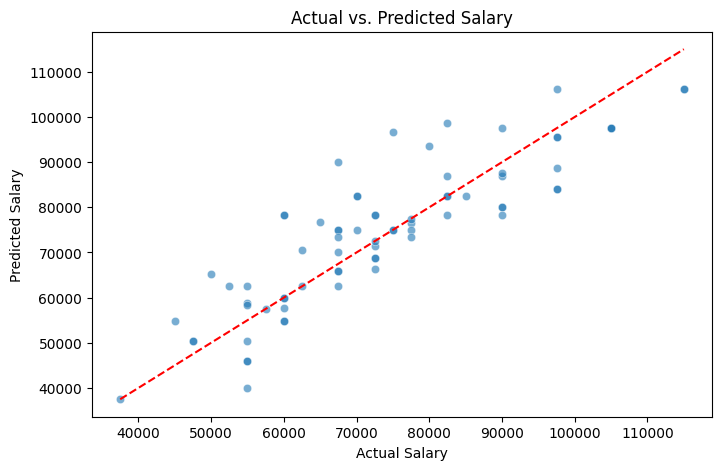

Top 20 Important Words in Job Descriptions: ['it', 'cloud', 'data', 'design', 'analyze', 'manage', 'develop', 'software', 'analysis', 'provide', 'support', 'ensure', 'compliance', 'management', 'procurement', 'azure', 'aws', 'troubleshooting', 'security', 'windows']


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Load the dataset with proper encoding
file_path = "Job opportunities.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1")

# Standardize column names by stripping spaces and converting to lowercase
df.columns = df.columns.str.strip().str.lower()

# Check if necessary columns exist
required_columns = ['job title', 'job description', 'required skills', 'company', 'salary range']
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"Warning: The following required columns are missing: {missing_columns}")
else:
    # Text feature extraction (Skills + Job Description)
    df['combined_text'] = df['required skills'].fillna('') + ' ' + df['job description'].fillna('')

    # Convert text into numerical features using TF-IDF
    vectorizer = TfidfVectorizer()
    features = vectorizer.fit_transform(df['combined_text'])

    # Preprocess salary range: Extract average salary
    def extract_avg_salary(salary):
        salary = re.sub(r'[^0-9\-]', '', str(salary))  # Remove non-numeric characters except '-'
        if '-' in salary:
            parts = salary.split('-')
            if len(parts) == 2:
                return (float(parts[0]) + float(parts[1])) / 2  # Take the average
        try:
            return float(salary)
        except ValueError:
            return None  # Handle missing or invalid values

    df['salary range'] = df['salary range'].apply(extract_avg_salary)
    df = df.dropna(subset=['salary range'])  # Drop rows with missing salary
    target = df['salary range']

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

    # Train a linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate mean absolute error
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Mean Absolute Error: {mae:.2f}")

    # Visualization: Salary Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df['salary range'], bins=30, kde=True, color='blue')
    plt.title("Salary Distribution")
    plt.xlabel("Salary Range")
    plt.ylabel("Count")
    plt.show()

    # Visualization: Actual vs. Predicted Salary
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.title("Actual vs. Predicted Salary")
    plt.show()

    # Display important words from TF-IDF
    feature_array = vectorizer.get_feature_names_out()
    tfidf_sorting = features.sum(axis=0).A1.argsort()[::-1]
    top_words = [feature_array[i] for i in tfidf_sorting[:20]]
    print("Top 20 Important Words in Job Descriptions:", top_words)


Successfully loaded with latin-1 encoding

SALARY PREDICTION RESULTS:
MAE: $5,784.34
R² Score: 0.807
Cross-validated R²: 0.698 (±0.210)


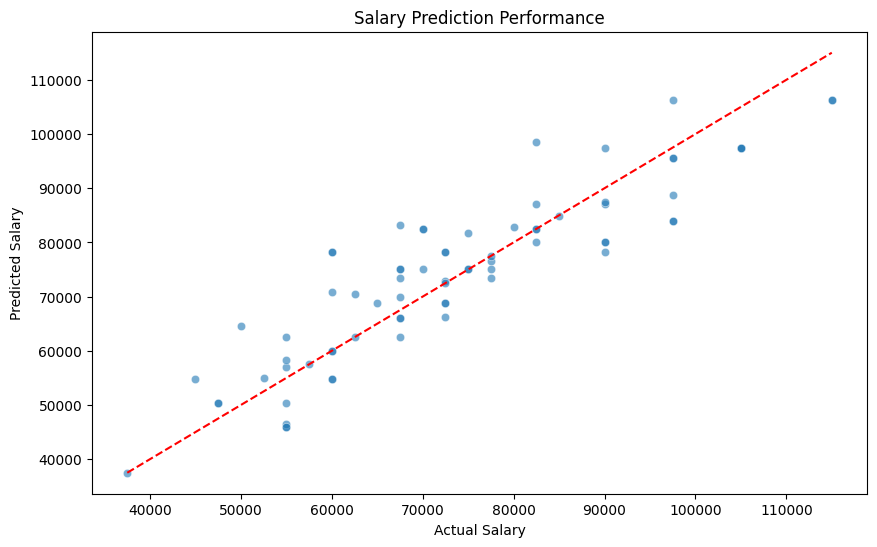


JOB TYPE CLASSIFICATION RESULTS:
Accuracy: 1.000

Classification Report:
              precision    recall  f1-score   support

   Full-Time       1.00      1.00      1.00        73

    accuracy                           1.00        73
   macro avg       1.00      1.00      1.00        73
weighted avg       1.00      1.00      1.00        73



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


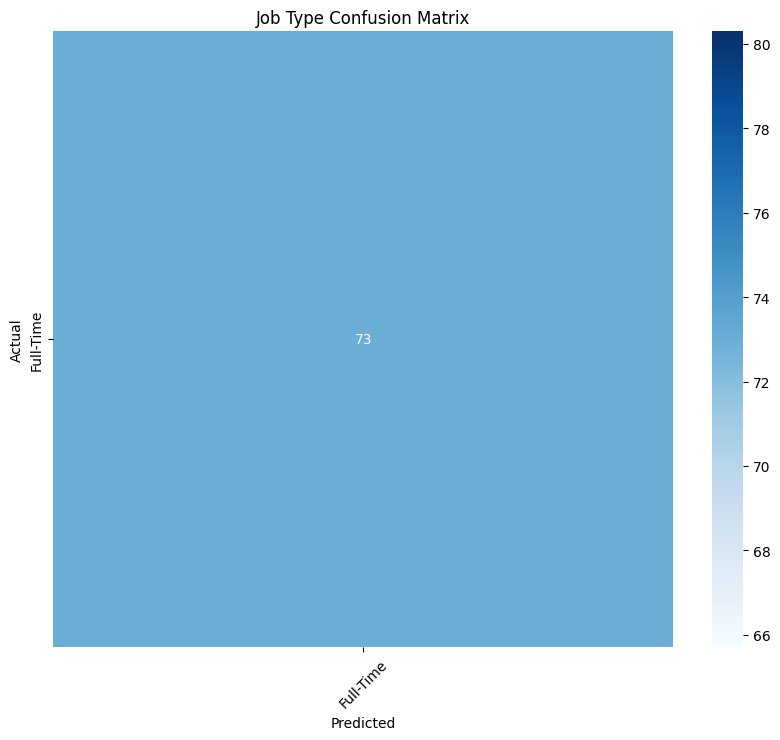

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, r2_score,
                           accuracy_score, classification_report,
                           confusion_matrix)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Load dataset with multiple encoding attempts
def load_job_data(filepath):
    encodings = ['utf-8', 'latin-1', 'ISO-8859-1']
    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, encoding=encoding)
            print(f"Successfully loaded with {encoding} encoding")
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError("Failed to load file with any encoding")

df = load_job_data("/Job opportunities.csv")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# --------------------------
# 1. SALARY PREDICTION (REGRESSION)
# --------------------------

def preprocess_salary(df):
    """Improved salary range processing"""
    def extract_salary(s):
        if pd.isna(s) or str(s).lower() in ['negotiable', 'competitive', 'na']:
            return np.nan

        # Find all numeric values in the string
        numbers = [float(x.replace(',', ''))
                  for x in re.findall(r'\d{1,3}(?:,\d{3})*(?:\.\d+)?', str(s))]

        if not numbers:
            return np.nan
        return np.mean(numbers)  # Return average if multiple numbers

    df['salary'] = df['salary_range'].apply(extract_salary)
    df = df.dropna(subset=['salary'])
    return df

if 'salary_range' in df.columns:
    df = preprocess_salary(df)

    # Create combined text features
    text_features = ['job_description', 'required_skills', 'job_title']
    df['combined_text'] = df[text_features].fillna('').apply(' '.join, axis=1)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        df['combined_text'],
        df['salary'],
        test_size=0.2,
        random_state=42
    )

    # Build pipeline with proper feature extraction
    salary_pipe = make_pipeline(
        TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2)),
        LinearRegression()
    )

    # Train and evaluate
    salary_pipe.fit(X_train, y_train)
    y_pred = salary_pipe.predict(X_test)

    print("\nSALARY PREDICTION RESULTS:")
    print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
    print(f"R² Score: {r2_score(y_test, y_pred):.3f}")

    # Cross-validation
    cv_scores = cross_val_score(salary_pipe, df['combined_text'], df['salary'],
                              cv=5, scoring='r2')
    print(f"Cross-validated R²: {np.mean(cv_scores):.3f} (±{np.std(cv_scores):.3f})")

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.title("Salary Prediction Performance")
    plt.show()

# --------------------------
# 2. JOB TYPE CLASSIFICATION
# --------------------------

if 'job_type' in df.columns:
    # Create text features
    df['job_text'] = df['job_title'].fillna('') + " " + df['job_description'].fillna('')

    # Filter out rare job types
    type_counts = df['job_type'].value_counts()
    common_types = type_counts[type_counts > 10].index
    df = df[df['job_type'].isin(common_types)]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        df['job_text'],
        df['job_type'],
        test_size=0.2,
        random_state=42,
        stratify=df['job_type']
    )

    # Build classification pipeline
    class_pipe = make_pipeline(
        CountVectorizer(max_features=800, stop_words='english'),
        MultinomialNB()
    )

    # Train and evaluate
    class_pipe.fit(X_train, y_train)
    y_pred = class_pipe.predict(X_test)

    print("\nJOB TYPE CLASSIFICATION RESULTS:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d',
                cmap='Blues',
                xticklabels=class_pipe.classes_,
                yticklabels=class_pipe.classes_)
    plt.title("Job Type Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45)
    plt.show()

# --------------------------
# 3. NUMERIC FEATURE ANALYSIS (if numeric columns exist)
# --------------------------

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if len(numeric_cols) > 1:
    print("\nNUMERIC FEATURE ANALYSIS:")
    # Correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Numeric Feature Correlations")
    plt.show()

    # Pairplot for first 5 numeric features
    sns.pairplot(df[numeric_cols[:5]])
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load your dataset
df = pd.read_csv("/Job opportunities.csv", encoding='latin-1')  # Replace with your dataset path

# Optional: Downsample the majority class (e.g., Full-Time) to reduce class imbalance
df_majority = df[df['Job Type'] == 'Full-Time']
df_minority = df[df['Job Type'] != 'Full-Time']

# Check if the minority class has any samples before downsampling
if len(df_minority) > 0:
    df_majority_downsampled = resample(df_majority,
                                       replace=False,
                                       n_samples=len(df_minority),
                                       random_state=42)

    df_balanced = pd.concat([df_majority_downsampled, df_minority])
else:
    print("Warning: Minority class has no samples. Skipping downsampling.")
    df_balanced = df  # Use the original dataset without downsampling

# Feature and target selection
X = df_balanced.drop("Job Type", axis=1)
y = df_balanced["Job Type"]

# Convert categorical features to numerical using Label Encoding
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Limit model complexity
model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)

# Prediction and evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

   Full-Time       1.00      1.00      1.00        73

    accuracy                           1.00        73
   macro avg       1.00      1.00      1.00        73
weighted avg       1.00      1.00      1.00        73

